In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("ex4.csv")

# 建立本章會用到的教學目標欄位
data["hasType2"] = data["Type2"].notna().astype(int)
data["isLegendary"] = data["Legendary"].astype(int)

feature_names = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

work_data = data.copy()

X = work_data[feature_names]
y = work_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("測試資料 Accuracy：", accuracy_score(y_test, y_pred))
print("測試資料 F1-score：", f1_score(y_test, y_pred))

print("混淆矩陣：")
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=["實際沒有第二屬性", "實際有第二屬性"],
    columns=["預測沒有第二屬性", "預測有第二屬性"]
)

display(cm)

print("分類報告：")
print(classification_report(y_test, y_pred))

newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

newData_scaled = scaler.transform(newData)
new_pred = model.predict(newData_scaled)
new_prob = model.predict_proba(newData_scaled)

new_result = pd.DataFrame({
    "預測是否有第二屬性": new_pred,
    "沒有第二屬性的機率": new_prob[:, 0],
    "有第二屬性的機率": new_prob[:, 1]
})

print("新資料預測結果：")
display(new_result)

測試資料 Accuracy： 0.6071428571428571
測試資料 F1-score： 0.6333333333333333
混淆矩陣：


,預測沒有第二屬性,預測有第二屬性
實際沒有第二屬性,60,45
實際有第二屬性,43,76


分類報告：
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       105
           1       0.63      0.64      0.63       119

    accuracy                           0.61       224
   macro avg       0.61      0.61      0.61       224
weighted avg       0.61      0.61      0.61       224

新資料預測結果：


c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,預測是否有第二屬性,沒有第二屬性的機率,有第二屬性的機率
0,0,0.572588,0.427412
1,1,0.031673,0.968327


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2

pipe_data = data.copy()

numeric_features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
categorical_features = ["Type1", "Generation"]

X = pipe_data[numeric_features + categorical_features]
y = pipe_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

numeric_preprocess = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=4))
])

categorical_preprocess = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ("select", SelectKBest(score_func=chi2, k=6))
])

preprocess = ColumnTransformer([
    ("numeric", numeric_preprocess, numeric_features),
    ("categorical", categorical_preprocess, categorical_features)
])

pipeline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

print("Pipeline 測試資料 Accuracy：", accuracy_score(y_test, y_pred))
print("Pipeline 測試資料 F1-score：", f1_score(y_test, y_pred))
print("分類報告：")
print(classification_report(y_test, y_pred))

Pipeline 測試資料 Accuracy： 0.6071428571428571
Pipeline 測試資料 F1-score： 0.6333333333333333
分類報告：
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       105
           1       0.63      0.64      0.63       119

    accuracy                           0.61       224
   macro avg       0.61      0.61      0.61       224
weighted avg       0.61      0.61      0.61       224



In [31]:
from sklearn.model_selection import StratifiedKFold

cv_data = data.copy()

X = cv_data[feature_names]
y = cv_data["hasType2"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fold_rows = []
fold_number = 1

for train_index, valid_index in skf.split(X, y):
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]
    y_train_fold = y.iloc[train_index]
    y_valid_fold = y.iloc[valid_index]

    fold_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
    ])

    fold_model.fit(X_train_fold, y_train_fold)

    train_pred = fold_model.predict(X_train_fold)
    valid_pred = fold_model.predict(X_valid_fold)

    row = {
        "fold": fold_number,
        "train_accuracy": accuracy_score(y_train_fold, train_pred),
        "valid_accuracy": accuracy_score(y_valid_fold, valid_pred),
        "train_f1": f1_score(y_train_fold, train_pred),
        "valid_f1": f1_score(y_valid_fold, valid_pred)
    }
    
    fold_rows.append(row)

    fold_number = fold_number + 1

fold_result = pd.DataFrame(fold_rows)

print("每一個 fold 的訓練與驗證結果：")
display(fold_result)

print("\n平均驗證 Accuracy：", fold_result["valid_accuracy"].mean())
print("平均驗證 F1-score：", fold_result["valid_f1"].mean())

每一個 fold 的訓練與驗證結果：


,fold,train_accuracy,valid_accuracy,train_f1,valid_f1
0,1,0.600000,0.541899,0.629534,0.590000
1,2,0.598601,0.592179,0.636248,0.647343
2,3,0.591608,0.597765,0.636816,0.640000
3,4,0.611189,0.536313,0.649874,0.582915
4,5,0.579609,0.617978,0.624220,0.660000



平均驗證 Accuracy： 0.5772267905341787
平均驗證 F1-score： 0.6240515136066808


In [32]:
from sklearn.tree import DecisionTreeClassifier

fit_data = data.copy()

X = fit_data[feature_names]
y = fit_data["hasType2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

tree_underfit = DecisionTreeClassifier(max_depth=1, random_state=0)
tree_underfit.fit(X_train, y_train)

tree_reasonable = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=0)
tree_reasonable.fit(X_train, y_train)

tree_overfit = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=0)
tree_overfit.fit(X_train, y_train)

rows = []

train_pred = tree_underfit.predict(X_train)
test_pred = tree_underfit.predict(X_test)
rows.append({
    "模型": "max_depth=1，容易欠擬合",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

train_pred = tree_reasonable.predict(X_train)
test_pred = tree_reasonable.predict(X_test)
rows.append({
    "模型": "max_depth=3，較簡單且穩定",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

train_pred = tree_overfit.predict(X_train)
test_pred = tree_overfit.predict(X_test)
rows.append({
    "模型": "max_depth=None，容易過擬合",
    "train_accuracy": accuracy_score(y_train, train_pred),
    "test_accuracy": accuracy_score(y_test, test_pred)
})

fit_result = pd.DataFrame(rows)
display(fit_result)

,模型,train_accuracy,test_accuracy
0,max_depth=1，容易欠擬合,0.605970,0.620536
1,max_depth=3，較簡單且穩定,0.640299,0.611607
2,max_depth=None，容易過擬合,0.995522,0.575893


In [33]:
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve

curve_data = data.copy()

X = curve_data[feature_names]
y = curve_data["hasType2"]

curve_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

train_sizes = np.linspace(0.2, 1.0, 5)

train_sizes_abs, train_scores, valid_scores = learning_curve(
    curve_model,
    X,
    y,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy"
)

learning_summary = pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_score_mean": train_scores.mean(axis=1),
    "valid_score_mean": valid_scores.mean(axis=1),
    "train_score_std": train_scores.std(axis=1),
    "valid_score_std": valid_scores.std(axis=1)
})

C_values = np.array([0.01, 0.1, 1, 10, 100])

train_scores_v, valid_scores_v = validation_curve(
    curve_model,
    X,
    y,
    param_name="model__C",
    param_range=C_values,
    cv=cv,
    scoring="accuracy"
)

validation_summary = pd.DataFrame({
    "C": C_values,
    "train_score_mean": train_scores_v.mean(axis=1),
    "valid_score_mean": valid_scores_v.mean(axis=1),
    "train_score_std": train_scores_v.std(axis=1),
    "valid_score_std": valid_scores_v.std(axis=1)
})

print("學習曲線摘要：")
display(learning_summary)

print("\n驗證曲線摘要：")
display(validation_summary)

學習曲線摘要：


,train_size,train_score_mean,valid_score_mean,train_score_std,valid_score_std
0,143,0.636364,0.539169,0.019278,0.025275
1,286,0.594406,0.558207,0.009639,0.044305
2,429,0.586480,0.582838,0.018566,0.033303
3,572,0.579021,0.575017,0.013333,0.038501
4,715,0.595524,0.577227,0.011513,0.032336



驗證曲線摘要：


,C,train_score_mean,valid_score_mean,train_score_std,valid_score_std
0,0.01,0.585853,0.583931,0.006075,0.022956
1,0.10,0.593403,0.578350,0.007047,0.033797
2,1.00,0.596202,0.577227,0.010404,0.032336
3,10.00,0.595642,0.578344,0.009751,0.033113
4,100.00,0.595642,0.578344,0.009670,0.033113


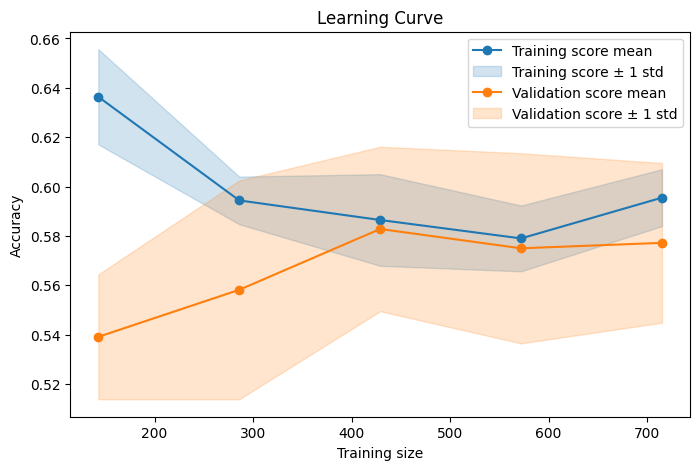

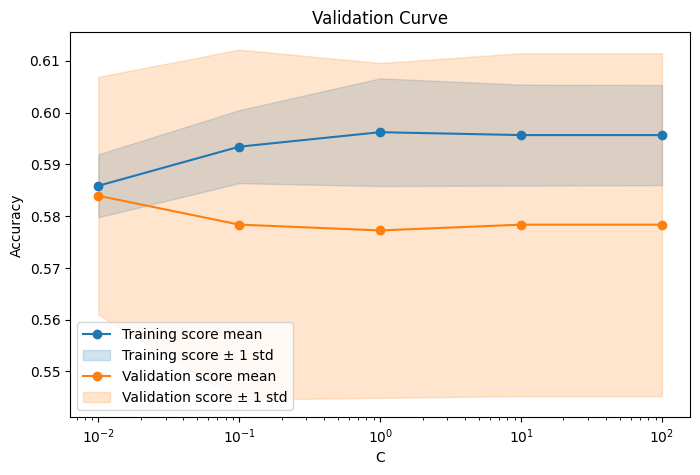

In [34]:
learning_x = learning_summary["train_size"].to_numpy()

learning_train_mean = learning_summary["train_score_mean"].to_numpy()
learning_train_std = learning_summary["train_score_std"].to_numpy()
learning_train_lower = np.clip(learning_train_mean - learning_train_std, 0, 1)
learning_train_upper = np.clip(learning_train_mean + learning_train_std, 0, 1)

learning_valid_mean = learning_summary["valid_score_mean"].to_numpy()
learning_valid_std = learning_summary["valid_score_std"].to_numpy()
learning_valid_lower = np.clip(learning_valid_mean - learning_valid_std, 0, 1)
learning_valid_upper = np.clip(learning_valid_mean + learning_valid_std, 0, 1)

plt.figure(figsize=(8, 5))

train_line = plt.plot(
    learning_x,
    learning_train_mean,
    marker="o",
    label="Training score mean"
)[0]
plt.fill_between(
    learning_x,
    learning_train_lower,
    learning_train_upper,
    alpha=0.2,
    color=train_line.get_color(),
    label="Training score ± 1 std"
)

valid_line = plt.plot(
    learning_x,
    learning_valid_mean,
    marker="o",
    label="Validation score mean"
)[0]
plt.fill_between(
    learning_x,
    learning_valid_lower,
    learning_valid_upper,
    alpha=0.2,
    color=valid_line.get_color(),
    label="Validation score ± 1 std"
)

plt.xlabel("Training size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
# plt.ylim(0, 1.05)
plt.legend()
plt.show()


validation_x = validation_summary["C"].to_numpy()

validation_train_mean = validation_summary["train_score_mean"].to_numpy()
validation_train_std = validation_summary["train_score_std"].to_numpy()
validation_train_lower = np.clip(validation_train_mean - validation_train_std, 0, 1)
validation_train_upper = np.clip(validation_train_mean + validation_train_std, 0, 1)

validation_valid_mean = validation_summary["valid_score_mean"].to_numpy()
validation_valid_std = validation_summary["valid_score_std"].to_numpy()
validation_valid_lower = np.clip(validation_valid_mean - validation_valid_std, 0, 1)
validation_valid_upper = np.clip(validation_valid_mean + validation_valid_std, 0, 1)

plt.figure(figsize=(8, 5))

train_line = plt.semilogx(
    validation_x,
    validation_train_mean,
    marker="o",
    label="Training score mean"
)[0]
plt.fill_between(
    validation_x,
    validation_train_lower,
    validation_train_upper,
    alpha=0.2,
    color=train_line.get_color(),
    label="Training score ± 1 std"
)

valid_line = plt.semilogx(
    validation_x,
    validation_valid_mean,
    marker="o",
    label="Validation score mean"
)[0]
plt.fill_between(
    validation_x,
    validation_valid_lower,
    validation_valid_upper,
    alpha=0.2,
    color=valid_line.get_color(),
    label="Validation score ± 1 std"
)

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation Curve")
# plt.ylim(0, 1.05)
plt.legend()
plt.show()

Average Precision： 0.6984683013794916
ROC-AUC： 0.9230392156862745


C:\Users\student\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


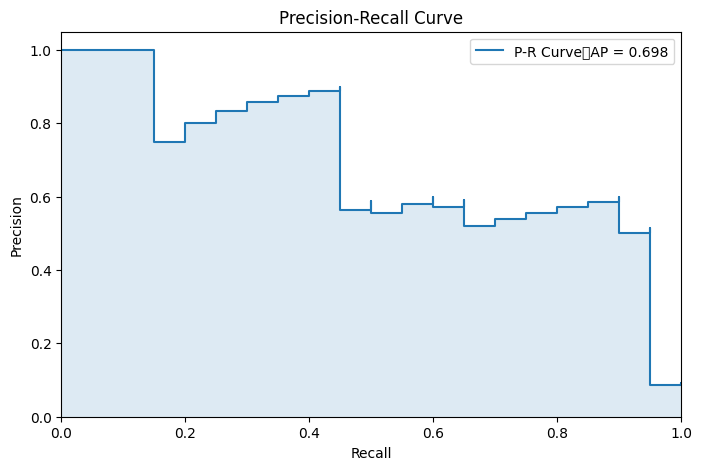

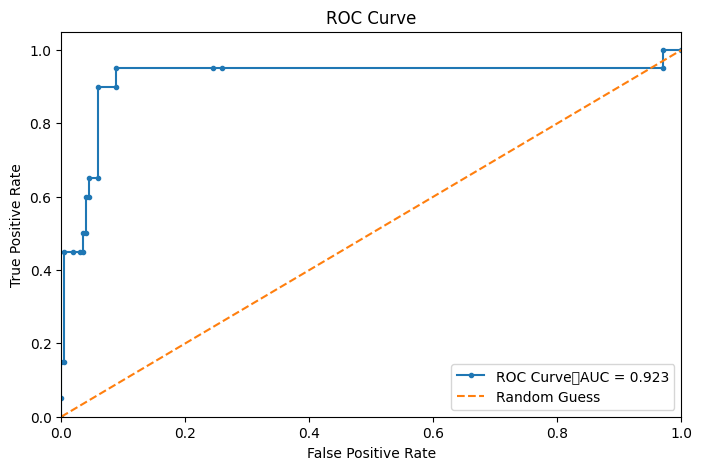

In [35]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

pr_data = data.copy()

X = pr_data[feature_names]
y = pr_data["isLegendary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

pr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

pr_model.fit(X_train, y_train)

positive_score = pr_model.predict_proba(X_test)[:, 1]

precision, recall, pr_thresholds = precision_recall_curve(y_test, positive_score)
fpr, tpr, roc_thresholds = roc_curve(y_test, positive_score)

average_precision = average_precision_score(y_test, positive_score)
roc_auc = roc_auc_score(y_test, positive_score)

print("Average Precision：", average_precision)
print("ROC-AUC：", roc_auc)

recall_plot = recall[::-1]
precision_plot = precision[::-1]

plt.figure(figsize=(8, 5))

plt.step(
    recall_plot,
    precision_plot,
    where="post",
    label=f"P-R Curve，AP = {average_precision:.3f}"
)

plt.fill_between(
    recall_plot,
    precision_plot,
    0,
    step="post",
    alpha=0.15
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    marker=".",
    label=f"ROC Curve，AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegressionCV

tune_data = data.copy()

X = tune_data[feature_names]
y = tune_data["hasType2"]

search_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=0))
])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2", "l1"],
    "model__solver": ["lbfgs", "liblinear"]
}
grid_search = GridSearchCV(
    search_model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="f1"
)
grid_search.fit(X, y)

param_random = {
    "model__C": np.logspace(-3, 2, 6),
    "model__penalty": ["l2", "l1"],
    "model__solver": ["lbfgs", "liblinear"]
}

random_search = RandomizedSearchCV(
    search_model,
    param_distributions=param_random,
    n_iter=4,
    cv=inner_cv,
    scoring="f1",
    random_state=0
)
random_search.fit(X, y)

scaler_for_cv = StandardScaler()
X_scaled = scaler_for_cv.fit_transform(X)
logistic_cv = LogisticRegressionCV(
    Cs=10,
    cv=inner_cv,
    scoring="f1",
    max_iter=1000,
    random_state=0
)
logistic_cv.fit(X_scaled, y)

nested_search = GridSearchCV(
    search_model,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="f1"
)
nested_scores = cross_val_score(
    nested_search,
    X,
    y,
    cv=outer_cv,
    scoring="f1"
)

tuning_result = pd.DataFrame({
    "方法": [
        "GridSearchCV",
        "RandomizedSearchCV",
        "LogisticRegressionCV",
        "Nested CV"
    ],
    "最佳或平均 F1": [
        grid_search.best_score_,
        random_search.best_score_,
        logistic_cv.scores_[1].mean(),
        nested_scores.mean()
    ],
    "重點結果": [
        str(grid_search.best_params_),
        str(random_search.best_params_),
        "best C = " + str(logistic_cv.C_[0]),
        "outer fold scores = " + str(nested_scores)
    ]
})

display(tuning_result)

c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' wa

,方法,最佳或平均 F1,重點結果
0,GridSearchCV,0.674294,"{'model__C': 0.001, 'model__penalty': 'l2', 'm..."
1,RandomizedSearchCV,0.617247,"{'model__solver': 'liblinear', 'model__penalty..."
2,LogisticRegressionCV,0.635209,best C = 0.0001
3,Nested CV,0.675513,outer fold scores = [0.68329177 0.67164179 0.6...


In [37]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours

imbalance_data = data.copy()

X = imbalance_data[feature_names]
y = imbalance_data["isLegendary"]

print("原始類別分布：")
display(y.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0
)

print("訓練資料類別分布：")
display(y_train.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

print("測試資料類別分布：")
display(y_test.value_counts().rename(index={0: "非傳奇", 1: "傳奇"}))

def evaluate_binary_model(model_name, model, X_train_input, y_train_input, X_test_input, y_test_input):
    model.fit(X_train_input, y_train_input)
    pred = model.predict(X_test_input)

    result = {
        "方法": model_name,
        "accuracy": accuracy_score(y_test_input, pred),
        "precision_傳奇": precision_score(y_test_input, pred, zero_division=0),
        "recall_傳奇": recall_score(y_test_input, pred, zero_division=0),
        "f1_傳奇": f1_score(y_test_input, pred, zero_division=0)
    }

    return result

def summarize_resampled_distribution(method_name, sampler):
    pereview_pipeline = ImbPipeline([
        ("scaler", StandardScaler()),
        ("sampler", sampler)
    ])

    X_resampled, y_resampled = pereview_pipeline.fit_resample(X_train, y_train)
    class_count = pd.Series(y_resampled).value_counts().sort_index()

    summary = {
        "方法": method_name,
        "非傳奇數量": class_count.get(0, 0),
        "傳奇數量": class_count.get(1, 0),
        "合計": len(y_resampled)
    }

    return summary



baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

balanced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=0))
])

smote_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", SMOTE(random_state=0)),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

tomek_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", TomekLinks()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

enn_model = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", EditedNearestNeighbours()),
    ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=0))
])

sampling_rows = []

sampling_rows.append({
    "方法": "原始訓練資料",
    "非傳奇數量": y_train.value_counts().get(0, 0),
    "傳奇數量": y_train.value_counts().get(1, 0),
    "合計": len(y_train)
})

sampling_rows.append(
    summarize_resampled_distribution("SMOTE 上採樣", SMOTE(random_state=0))
)

sampling_rows.append(
    summarize_resampled_distribution("TomekLinks 下採樣 / 邊界清理", TomekLinks())
)

sampling_rows.append(
    summarize_resampled_distribution("EditedNearestNeighbours 下採樣 / 近鄰清理", EditedNearestNeighbours())
)

print("不同 sampling 方法處理後的訓練資料類別分布：")
sampling_result = pd.DataFrame(sampling_rows)
display(sampling_result)


imbalance_rows = []

imbalance_rows.append(
    evaluate_binary_model("baseline", baseline_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("class_weight='balanced", balanced_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("SMOTE 上採樣", smote_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("TomekLinks 下採樣 / 邊界清理", tomek_model, X_train, y_train, X_test, y_test)
)

imbalance_rows.append(
    evaluate_binary_model("EditedNearestNeighbours 下採樣 / 近鄰清理", enn_model, X_train, y_train, X_test, y_test)
)

print("不同方法的模型評估結果：")
imbalance_result = pd.DataFrame(imbalance_rows)
display(imbalance_result)

原始類別分布：


isLegendary
非傳奇    815
傳奇      79
Name: count, dtype: int64

訓練資料類別分布：


isLegendary
非傳奇    611
傳奇      59
Name: count, dtype: int64

測試資料類別分布：


isLegendary
非傳奇    204
傳奇      20
Name: count, dtype: int64

不同 sampling 方法處理後的訓練資料類別分布：


,方法,非傳奇數量,傳奇數量,合計
0,原始訓練資料,611,59,670
1,SMOTE 上採樣,611,611,1222
2,TomekLinks 下採樣 / 邊界清理,603,59,662
3,EditedNearestNeighbours 下採樣 / 近鄰清理,559,59,618


不同方法的模型評估結果：


,方法,accuracy,precision_傳奇,recall_傳奇,f1_傳奇
0,baseline,0.946429,0.900000,0.45,0.600000
1,class_weight='balanced,0.910714,0.500000,0.95,0.655172
2,SMOTE 上採樣,0.928571,0.558824,0.95,0.703704
3,TomekLinks 下採樣 / 邊界清理,0.946429,0.900000,0.45,0.600000
4,EditedNearestNeighbours 下採樣 / 近鄰清理,0.924107,0.565217,0.65,0.604651
